# Final Assignment: analyses

This notebook contains the source code for all explainable methods and the analyses. (As you can see a lot of code from the notebook is copied from my training notebook).

## Download dataset

The following cell needs to be ran only once. It downloads and unzips the data. The unzip CLI tool might not be installed by default on Windows, so if you are using windows, please unzip manually into a folder called "data", or see the README.md.

In [1495]:
# Downloading the dataset (unzip might not be installed on Windows)
# !curl -L -o ./data.zip https://www.kaggle.com/api/v1/datasets/download/masoudnickparvar/brain-tumor-mri-dataset
# !unzip -d ./data ./data.zip

## Importing libraries

See README.md for installing dependencies :).

In [33]:
import os
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from typing import Callable
from torch.utils.data import DataLoader
from torchvision import models, datasets, transforms

## Setting the seed

Setting the seed for good reproducability :D

In [34]:
torch.manual_seed(21)  # Using my lucky number :D
np.random.seed(21)

## Setting the device used for analyses

Using `CPU`, because some of the operations require all data to be on CPU, and moving between them all the time creates unnecessary overhead. In addition, we are not training large batches, so using the cpu should suffice.

In [35]:
device = "cpu"

## Preparing the dataset

In [37]:
transform = transforms.Compose(
    [
        transforms.Resize((299, 299)),  # 299 is the minimal image size of InceptionV3
        transforms.ToTensor(),
        # transforms.Normalize(0.5, 0.5)
    ]
)

In [38]:
path = os.path.join("data", "Testing")

In [39]:
dataset = datasets.ImageFolder(
    root=path,
    transform=transform
)

In [40]:
loader = DataLoader(dataset, batch_size=16)

## Creating the model

### Loading pre-trained model

In [41]:
model = models.inception_v3(weights=models.Inception_V3_Weights)

/Users/daanwichmann/PycharmProjects/Explainable AI/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


### Adding custom classification head

In [42]:
model.fc = nn.Linear(in_features=2048, out_features=4)  # Got the input features from the sourcecode hihi

In [43]:
model = model.to(device)

## Explainable methods

The following tutorial was used for implementing GradCAM: https://medium.com/@stepanulyanin/implementing-grad-cam-in-pytorch-ea0937c31e82, and by looking way to deep into the PyTorch documentation on how to use hooks with pretrained modules, since I can't edit their source code but still need the activations and gradients :( (aaaaaaah).

### GradCAM

In [44]:
def grad_cam(
        model: nn.Module,
        X: torch.Tensor,
        y: int,
        last_conv_layer: nn.Module
) -> torch.Tensor:
    """Creates a Grad-CAM salience map of a images X, for target label y, using a specified conv layer."""
    resize = transforms.Resize((299, 299))

    def backward_hook(module, in_grad, out_grad):

        # Giving the last layer a new attribute with the activations gradient
        # Indexing because gradients is a 1-tuple
        last_conv_layer.gradients = out_grad[0]

    def forward_hook(module, args, outputs):
        last_conv_layer.activations = outputs  # Fiving the last layer a new attribute with the activations itself


    last_conv_layer.register_full_backward_hook(backward_hook)
    last_conv_layer.register_forward_hook(forward_hook)

    model.zero_grad()  # Resetting grad, to make sure we don't accumulate it
    y_pred = model(X)
    y_pred[:, y].backward()  # Calling backwards wrt the desired class.

    gradients = last_conv_layer.gradients[0]
    activations = last_conv_layer.activations.detach()  # Detaching  since numpy can't handle tensors with grad

    pooled_gradients = torch.mean(gradients, (1, 2))

    feature_maps = pooled_gradients.shape[0]
    for i in range(feature_maps):
        activations[:, i, :, :] *= pooled_gradients[i]

    heatmap = torch.mean(activations, dim=1).squeeze()  # Averaging the channels
    heatmap = np.maximum(heatmap, 0)  # Performing linear rectifier
    heatmap /= torch.max(heatmap)  # Normalizing the output of the heatmap between 0 and 1

    return resize(heatmap.unsqueeze(0)).squeeze()

### Vanilla Gradient

In [45]:
def vanilla_gradient(
        model: nn.Module,
        X: torch.Tensor,
        y: int,
) -> torch.Tensor:
    """Creates a salience map using vanilla gradient using input image X with respect to class y"""

    X.requires_grad = True  # Making sure gradient of input image is calculated

    model.zero_grad()  # Resetting grad, to make sure we don't accumulate it
    y_pred = model(X)
    y_pred[:, y].backward()

    return X.grad.squeeze(0).abs().mean(dim=0)

### Smoothgrad

In [47]:
def smooth_grad(
        model: nn.Module,
        X: torch.Tensor,
        y: int,
        grad_method: Callable,
        N: int,
        sigma: float,
        *args,
        **kwargs,
) -> torch.Tensor:
    """Applies Smoothgrad to a gradient-based method (e.g. Grad-CAM, vanilla gradients)."""

    # Creating the noisy images by adding Gaussian noise
    noisy_images = torch.zeros((N,) + X.shape)
    for i in range(N):
        g = sigma * torch.randn_like(X)
        noisy_images[i] = (X + g).detach()
        noisy_images[i].requires_grad = True

    # Computing the saliency maps from the gradient based method
    # In my case this will ofc be Grad-CAM, but I like to make
    # things generalized :).
    heatmaps = torch.zeros((N, 299, 299))
    for i in range(N):
        heatmaps[i] = grad_method(model, noisy_images[i], y, *args, **kwargs)

    return heatmaps.mean(dim=0)

### Guided Grad-CAM

In [49]:
def guided_grad_cam(
        model: nn.Module,
        X: torch.Tensor,
        y: int,
        last_conv_layer: nn.Module
) -> torch.Tensor:
    """Uses vanilla gradient and Grad-CAM to compute Guided Grad-CAM salience map"""

    heatmap_grad_cam = grad_cam(model, X, y, last_conv_layer)
    heatmap_vanilla_grad = vanilla_gradient(model, X, y)

    return heatmap_grad_cam * heatmap_vanilla_grad

## Inspecting explanation results

### Creating dictionary for label names

In [50]:
LABELS = {
    0: "glioma",
    1: "meningioma",
    2: "notumor",
    3: "pituitary",
}

### Loading model parameters

In [51]:
path = os.path.join("weights", "model-94.pth")
model.load_state_dict(torch.load(path, map_location=device))

<All keys matched successfully>

### Inspecting examples

In [52]:
def plot_explanation(ax, image, heatmap):
    """Plots an image + explanation on a pyplot subplot ax"""

    ax.imshow(image)
    ax.imshow(heatmap, cmap='jet', alpha=0.5)
    ax.set_yticklabels([])
    ax.set_xticklabels([])

Predicted: meningioma
Actual: meningioma


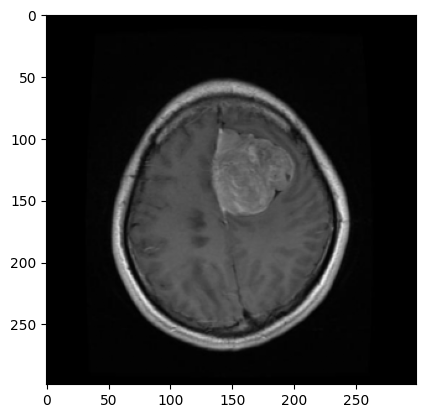

In [63]:
model.eval()

i = 512  # Change this variable to look at different images (good ones: 5, 512, 500)

X, y = dataset[i]
X = X.unsqueeze(0)
y_pred = torch.argmax(model(X), dim=1)

print(f"Predicted: {LABELS[y_pred.item()]}")
print(f"Actual: {LABELS[y]}")

image_show = X[0].permute((1, 2, 0)).numpy()
plt.imshow(image_show)
plt.show()

In [64]:
N = 20
sigma = 0.15
last_conv_layer = model.Mixed_7c
resize = transforms.Resize((299, 299))

/var/folders/gq/4p5dh4bn5ms2p4hx6dp6rzs40000gn/T/ipykernel_58223/3377161907.py:37: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  heatmap = np.maximum(heatmap, 0)  # Performing linear rectifier


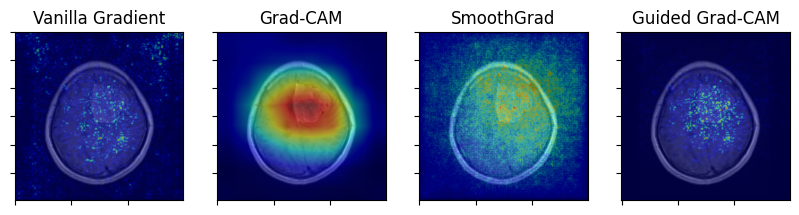

In [65]:
fig, axis = plt.subplots(1, 4, figsize=(10, 5))

heatmaps = []
methods = [
    "Vanilla Gradient",
    "Grad-CAM",
    "SmoothGrad",
    "Guided Grad-CAM"
]

heatmaps.append(vanilla_gradient(model, X, y))
heatmaps.append(grad_cam(model, X, y, last_conv_layer))
heatmaps.append(smooth_grad(model, X, y, vanilla_gradient, N, sigma))
heatmaps.append(guided_grad_cam(model, X, y, last_conv_layer))

for i, method in enumerate(methods):
    plot_explanation(axis[i], image_show, heatmaps[i])
    axis[i].set_title(method)

## Analyses

### Defining functions used for plotting & evaluation

In [56]:
def localization_acc(heatmap, bbox, N) -> float:
    """Calculates localization accuracy using the pointing game"""

    hits = 0

    flat = torch.flatten(heatmap)
    arg_sort = torch.argsort(flat, descending=True)  # Taking argmax to use max pixel each time
    _, w = heatmap.shape  # Getting the width of the image/salience map

    for idx in arg_sort[:N]:
        x = idx % w
        y = idx // w

        # Checking whether the pixel falls into the bounding box
        if bbox[1][1] > y > bbox[0][1] and bbox[1][0] > x > bbox[0][0]:
            hits += 1
        else:
            pass

    return hits / N  # hits / hits + misses

In [57]:
def plot_acc_explanations(axs, bbox, N, X, y, weights, method, *args, **kwargs):
    """
    Calculates localization accurasies and plots explanations for a method using
    the specified models from weights (path, accuracy).
    """

    loc_accs = []

    for i, (weights_, acc) in enumerate(weights):

        # Loading correct model
        model.load_state_dict(torch.load(weights_, map_location=device))

        # Computing salience map
        heatmap = method(model, X, y, *args, **kwargs)

        # Plotting image + explanation
        image = X.detach().squeeze().permute((1, 2, 0))  # Making tensor/array compatible with pyplot
        plot_explanation(axs[i], image, heatmap)
        axs[i].set_title(f"{acc}%")

        # Printing prediction
        y_pred = model(X).argmax(dim=1).item()  # Obtaining the prediction
        print(f"Predicted: {LABELS[y_pred]} (Actual: {LABELS[y]})")

        # Printing localization accuracy
        loc_acc = localization_acc(heatmap, bbox, N)
        loc_accs.append(loc_acc)
        print(f"Localization accuracy (model: {acc}%): {loc_acc}")

    return loc_accs

### Inspecting image, label, and prediction

In [58]:
BBOXES = {
    5: ((90, 10), (240, 140))  # ((min_x, min_y), (max_x, max_y))
}

Predicted: glioma
Actual: glioma


/var/folders/gq/4p5dh4bn5ms2p4hx6dp6rzs40000gn/T/ipykernel_58223/1646384193.py:25: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


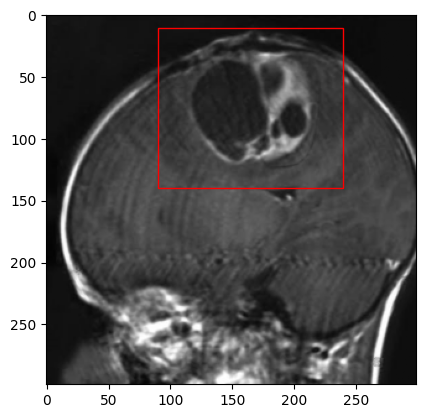

In [59]:
i = 5  # Change this variable to look at different images (good ones: 5, 512, 500)
N = 100  # Top N points to use in pointing game for localization accuracy.

X, y = dataset[i]
X = X.unsqueeze(0)
bbox = BBOXES[i]
y_pred = torch.argmax(model(X), dim=1)

print(f"Predicted: {LABELS[y_pred.item()]}")
print(f"Actual: {LABELS[y]}")

fig, ax = plt.subplots()
image = X[0].permute((1, 2, 0)).numpy()
rect = patches.Rectangle(
    xy=bbox[0],
    width=bbox[1][0] - bbox[0][0],
    height=bbox[1][1] - bbox[0][1],
    linewidth=1,
    edgecolor='r',
    facecolor='none'
)

ax.imshow(image)
ax.add_patch(rect)
fig.show()

### Plotting explanations as a function of model accuracy

In [60]:
weights = [
    ("model-70.pth", 70),
    ("model-80.pth", 80),
    ("model-86.pth", 86),
    ("model-94.pth", 94),
]  # (path, accuracy)

# Making sure we are in the correct dir on every os
weights = list(map(lambda x: (os.path.join("weights", x[0]), x[1]), weights))

Vanilla Gradient
Predicted: glioma (Actual: glioma)
Localization accuracy (model: 70%): 0.2708664235699425
Predicted: glioma (Actual: glioma)
Localization accuracy (model: 80%): 0.2848482136864947
Predicted: glioma (Actual: glioma)
Localization accuracy (model: 86%): 0.30008277219748997
Predicted: glioma (Actual: glioma)
Localization accuracy (model: 94%): 0.30822576676137
Grad-CAM


/var/folders/gq/4p5dh4bn5ms2p4hx6dp6rzs40000gn/T/ipykernel_58223/3377161907.py:37: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  heatmap = np.maximum(heatmap, 0)  # Performing linear rectifier


Predicted: glioma (Actual: glioma)
Localization accuracy (model: 70%): 0.38540524820473815


/var/folders/gq/4p5dh4bn5ms2p4hx6dp6rzs40000gn/T/ipykernel_58223/3377161907.py:37: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  heatmap = np.maximum(heatmap, 0)  # Performing linear rectifier


Predicted: glioma (Actual: glioma)
Localization accuracy (model: 80%): 0.3990514753584931


...

Predicted: glioma (Actual: glioma)
Localization accuracy (model: 80%): 0.3909308516587996


/var/folders/gq/4p5dh4bn5ms2p4hx6dp6rzs40000gn/T/ipykernel_58223/3377161907.py:37: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  heatmap = np.maximum(heatmap, 0)  # Performing linear rectifier


Predicted: glioma (Actual: glioma)
Localization accuracy (model: 86%): 0.40104248227109013


/var/folders/gq/4p5dh4bn5ms2p4hx6dp6rzs40000gn/T/ipykernel_58223/3377161907.py:37: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  heatmap = np.maximum(heatmap, 0)  # Performing linear rectifier


Predicted: glioma (Actual: glioma)
Localization accuracy (model: 94%): 0.41817856423793653


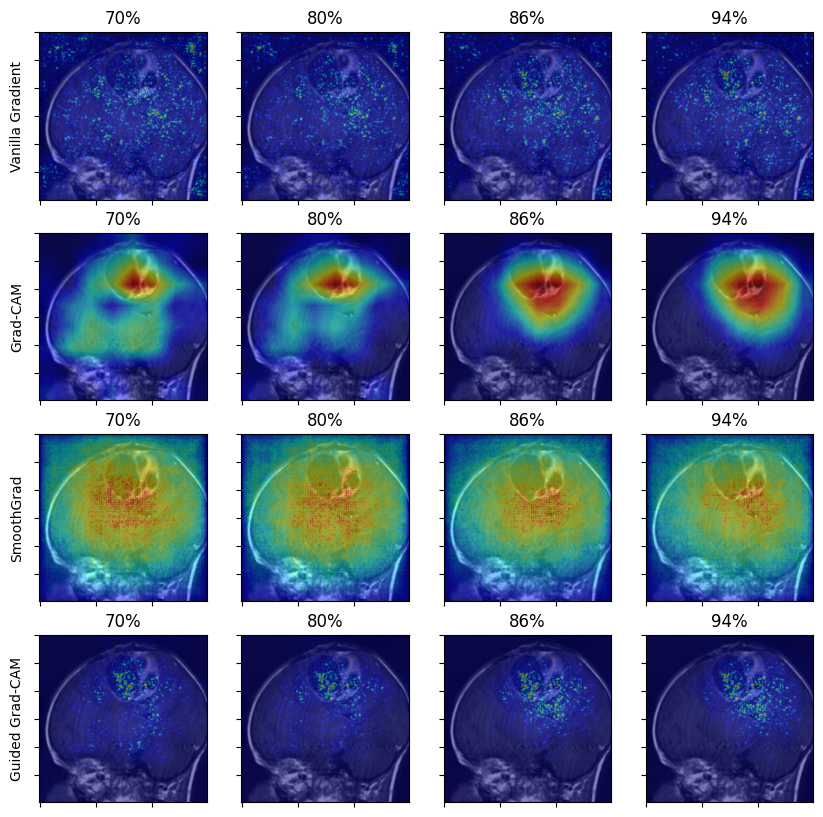

In [61]:
fig, axs = plt.subplots(4, len(weights), figsize=(10, 10))

top = 44_701  # Half of the number of pixels of the salience map
sigma = 0.15
last_conv_layer = model.Mixed_7c

print("Vanilla Gradient")
vanilla_gradient_accs = plot_acc_explanations(axs[0], bbox, top, X, y, weights, vanilla_gradient)

print("Grad-CAM")
grad_cam_accs = plot_acc_explanations(axs[1], bbox, top, X, y, weights, grad_cam, last_conv_layer)

print("SmoothGrad")
smoothgrad_accs = plot_acc_explanations(axs[2], bbox, top, X, y, weights, smooth_grad, vanilla_gradient, N, sigma)

print("Guided Grad-CAM")
guided_accs = plot_acc_explanations(axs[3], bbox, top, X, y, weights, guided_grad_cam, last_conv_layer)

for i, ax in enumerate(axs):
    ax[0].set(ylabel=methods[i])

### Plotting localization accuracies as a function of model accuracy

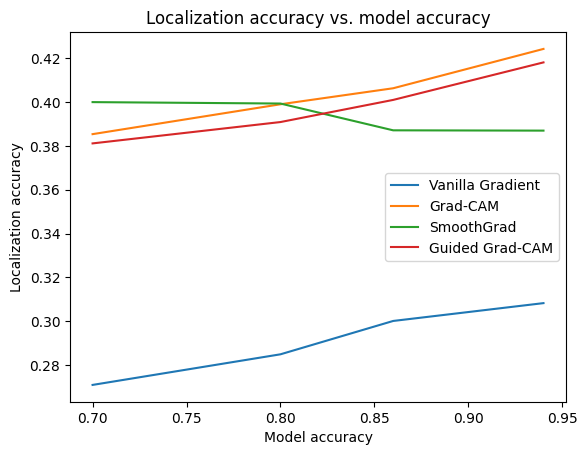

In [62]:
model_accs = [0.70, 0.80, 0.86, 0.94]

plt.plot(model_accs, vanilla_gradient_accs, label="Vanilla Gradient")
plt.plot(model_accs, grad_cam_accs, label="Grad-CAM")
plt.plot(model_accs, smoothgrad_accs, label="SmoothGrad")
plt.plot(model_accs, guided_accs, label="Guided Grad-CAM")

plt.legend()

plt.ylabel("Localization accuracy")
plt.xlabel("Model accuracy")
plt.title("Localization accuracy vs. model accuracy")

plt.show()